In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **MECS6616 Spring 2025 - Assignment 1: MPC & Forward Model**


***IMPORTANT:***
- **Before starting, make sure to read the [Assignment Instructions](https://courseworks2.columbia.edu/courses/237884/pages/assignment-instructions) page on Courseworks to understand the workflow and submission requirements for this project.**

***FOR Assignment 1!!!***
- Apart from the link to your notebook, you are also required to submit your collected data `.pkl` files and your chosen model checkpoint `.pth` files to Coursework. You will have two files for parts 2.
- Your part 2 files should be named `data_pt.pkl` and `dynamics_pt.pth`.
- You should put the link to your notebook in the "Comment" section of your submission.

## **Assignment Setup & Imports (do NOT change)**

***IMPORTANT:***
- Do NOT change this "*Assignment & Imports*" section
- Do NOT install any other dependencies or a different version of an already provided package. You may, however, import other packages

In [2]:
# ================================
# DO NOT MODIFY THIS CELL
# ================================
#
# This cell installs required system and Python dependencies.
# In particular, `dm_control` is installed to provide MuJoCo support.
# The installation may take a few seconds.
# Please run this cell before executing the rest of the notebook.

!apt-get install -qq -y libosmesa6-dev > /dev/null 2>&1
%pip install -q dm_control imageio imageio-ffmpeg

In [3]:
# ================================
# DO NOT MODIFY THIS CELL
# ================================
#
# Use off-screen rendering for MuJoCo (required in headless environments such as Colab)

import os
os.environ['MUJOCO_GL'] = 'osmesa'
from dm_control import suite
import numpy as np
import imageio
import base64
import io
from IPython.display import HTML
def show_video(frames, fps=30):
    """Display frames as MP4 video inline."""
    buf = io.BytesIO()
    imageio.mimsave(buf, frames, format='mp4', fps=fps)
    buf.seek(0)
    b64 = base64.b64encode(buf.read()).decode()
    return HTML(f'<video controls autoplay loop><source src="data:video/mp4;base64,{b64}" type="video/mp4"></video>')

## **Part1: Model Predictive Control (MPC) with GT Dynamics**

## Simulation Environment

In this assignment, we use **dm_control**, developed by Google DeepMind, to run MuJoCo-based simulations.  
Specifically, we access predefined control tasks through `dm_control.suite`, which provides a convenient interface to standard MuJoCo environments with a 0.01s simulation time step. In this assignment, we will use the task "half-cheetah".

Most necessary `dm_control` configurations have already been handled for you in this notebook, so you can focus on implementing the learning and control components of the assignment.

If you are interested in exploring additional features or customizing environments, we encourage you to review the official tutorial:  
https://colab.research.google.com/github/google-deepmind/dm_control/blob/main/tutorial.ipynb


In [4]:
#@title Example of MuJoco Usage using m_control {vertical-output: true}
# This cell demonstrates how to:
# 1. Load a MuJoCo environment using dm_control
# 2. Sample random actions
# 3. Step the simulator forward
# 4. Render frames and display a video
#
# You can modify this part to explore the functions of dmcontrol.suite

env = suite.load("cheetah", "run")

# Retrieve action space specification
spec = env.action_spec()

frames = []
env.reset()

duration = 2.0  # simulation duration (seconds)

# Run the environment with random actions
while env.physics.data.time < duration:
    action = np.random.uniform(spec.minimum, spec.maximum, spec.shape)
    env.step(action)
    frames.append(
        env.physics.render(camera_id=0, width=256, height=256)
    )

# Compute FPS for approximately real-time playback
fps = len(frames) / duration
print(f"{len(frames)} frames, {fps:.1f} fps for real-time playback")
env.close()
show_video(frames, fps=fps)

200 frames, 100.0 fps for real-time playback


## Vital Code Explanation for MPC Environment

To allow MPC to operate at a lower control frequency, we provide a wrapped environment class (`MPC_ENV_GT`) that internally manages the interaction with the original `dm_control` environment.

Instead of directly stepping the simulator at its native control timestep, this wrapper:

- Repeats each action multiple times
- Accumulates intermediate rewards
- Exposes a slower control frequency for MPC

This better reflects realistic control settings and significantly reduces computational cost during planning.

---

### About the Wrapped Environment

The `MPC_ENV_GT` class:

- Internally stores the original `dm_control` environment
- Computes the simulator frequency from `env.control_timestep()`
- Defines a lower MPC control frequency (e.g., 25 Hz)
- Repeats each action multiple simulator steps (`MPC_repeats`)
- Accumulates rewards across repeated steps
- Optionally records states and frames for visualization

From your perspective, you should interact with this wrapped environment rather than the raw `dm_control` environment.

The following interfaces are provided:

- `reset()`  
  Resets the environment to its default initial configuration.

- `get_state()`  
  Returns the full MuJoCo state of the cheetah as an 18-dimensional NumPy array.  
  The first 9 dimensions correspond to positions (including x, z, torso angle θ, and joint positions),  
  and the last 9 dimensions correspond to the associated velocities.  
  The state is ordered as:  
  `[positions (9), velocities (9)]`.

- `set_state(state)`  
  Sets the simulator to a specific 18-dimensional state and internally ensures dynamic consistency.  
  This is particularly important in MPC when rolling out multiple hypothetical trajectories from the **same initial state**.

- `step(action, record=False)`  
  Advances the simulator using a 7-dimensional torque vector.

  Internally, the same action is repeated for `MPC_repeats` simulator steps, and the intermediate rewards are accumulated into a single scalar. Thus, one call to `step()` corresponds to one MPC control step at the reduced control frequency.

  When `record=True`, the function additionally:
  - Saves a rendered frame
  - Stores the current joint positions (`qpos`)
  - Stores the current joint velocities (`qvel`)

  This is used for trajectory visualization and logging during rollout.

  The function returns the accumulated reward.

- `clear()`  
  Resets all internal logging buffers (e.g., recorded frames, positions, velocities).  
  This is useful when starting a new rollout or evaluation.

- `get_log()`  
  Returns the recorded visualization data, including rendered frames and logged state information.  
  This can be used for debugging and performance analysis.

These interfaces allow you to save, restore, and simulate trajectories efficiently within the MPC loop.

---

### Important Note

Although you do not need to directly use the low-level `dm_control` APIs in your implementation, understanding how the underlying simulator works (e.g., state representation, stepping, and reward computation) will help you better understand the overall structure of this assignment.

You are **not allowed to modify any code** in this class.

In [5]:
# ================================
# DO NOT MODIFY THIS CELL
# ================================
class MPC_ENV_GT:
    def __init__(self, env):
        self.env = env
        self.action_spec = env.action_spec()

        self.MPC_frequency = 25
        self.control_timestep = 1/self.MPC_frequency
        self.MPC_repeats = int(self.control_timestep/env.control_timestep())

        self.clear()

    def clear(self):
        # Initialize data collection lists
        self.frames = []  # Store rendered frames for video
        self.qposs = []  # Store states of the cheetah
        self.qvels = []  # Store velocities of the cheetah

    def reset(self):
        self.env.reset()

    def get_state(self):
        return self.env.physics.get_state()

    def set_state(self, state):
        self.env.physics.set_state(state)
        self.env.physics.forward()

    def step(self, action, record=False):
        reward = 0.0
        for _ in range(self.MPC_repeats):
            time_step = self.env.step(action)
            if time_step.reward:
              reward += time_step.reward
            else:
              reward += 0
        if record:
          self.frames.append(self.env.physics.render(camera_id=0, width=256, height=256))
          self.qposs.append(copy.deepcopy(self.env.physics.data.qpos))
          self.qvels.append(copy.deepcopy(self.env.physics.data.qvel))
        return reward

    def get_log(self):
        return self.frames, self.qposs, self.qvels

    def close(self):
        self.env.close()

## Implementing Model Predictive Control (MPC)

In this section, you will complete the `MPC` class by implementing the `plan` function.

You are free to add helper methods or modify the initialization logic as needed.  
However, during evaluation, an instance of your `MPC` class will be created and passed to a grading function.  
Therefore, **please ensure that the signature of the `plan` method remains unchanged.**

---

### Implementation Guidance

Below are some suggestions and considerations to help you design your controller:

1. **Computation vs. Performance Trade-off**

   The following hyperparameters directly affect the computational cost and control performance of MPC:

   - `planning_horizon`
   - `execution_horizon`
   - `samples_num`

   Larger values may improve performance but will significantly increase computation time.

---

2. **Sampling-Based Planning**

   The cheetah system has complex nonlinear dynamics.  
   A sampling-based approach is a practical solution.

   One possible strategy is:

   - Initialize a distribution over action sequences.
   - Sample multiple candidate sequences. **Remember to clip your actions to the valid range.**

   - Roll out trajectories using the simulator.
   - Evaluate their returns (or costs).
   - Refit the distribution using the top-performing (elite) samples.

   You may design the distribution and update rule as you see fit.
   
---

3. **Executing the Planned Actions**

   In standard MPC, only the **first action** of the optimized sequence is executed.

   Alternatively, you may execute multiple actions (`execution_horizon`) before replanning.  
   While this may reduce computational cost, it can degrade performance due to reduced feedback frequency.

---

4. **Shifting the Planning Distribution (Receding Horizon)**

   When entering the next planning cycle, you should discard the distributions corresponding to the actions that have already been executed.

   For example:

   - Suppose `planning_horizon = 10`
   - `execution_horizon = 2`
   - You maintain 10 action distributions (one per timestep in the horizon)

   After executing the first 2 actions:
   - Remove the first 2 distributions
   - Append 2 newly initialized distributions at the end

   This ensures that the total number of maintained distributions remains equal to `planning_horizon`.

   This shifting mechanism allows the controller to reuse useful information from the previous planning step while maintaining a fixed horizon length.

---

5. **Objective Design**

   Your goal is to make the cheetah move forward as much as possible **without falling**.

   You may:
   - Maximize accumulated reward, or
   - Minimize a custom-defined cost.

   To prevent falling, you may consider penalizing:
   - Large torso angles (e.g., excessive θ)
   - Excessively large control torques

   The design of the objective function is part of the task.


In [6]:
# from collections import deque

# class MPC:
# # ================================
# # YOUR CODE GOES HERE
#     def __init__(self, env, planning_horizon=15, execution_horizon=5, num_samples=200, top_k=50):

#         self.env = env
#         self.planning_horizon = planning_horizon
#         self.execution_horizon = execution_horizon
#         self.num_samples = num_samples
#         self.top_k = top_k

#         self.action_spec = env.action_spec
#         self.action_dim = self.action_spec.shape[0]
#         self.action_low = self.action_spec.minimum
#         self.action_high = self.action_spec.maximum

# # ================================

#     def plan(self, current_state):
# # ================================
# # YOUR CODE GOES HERE

#         # Initialize mean and std for Gaussian sampling
#         mean = np.zeros((self.planning_horizon, self.action_dim))
#         std = np.ones((self.planning_horizon, self.action_dim))

#         num_iterations = 3  # CEM refinement steps

#         for _ in range(num_iterations):

#             # Sample from Gaussian
#             action_sequences = np.random.normal(
#                 mean, std,
#                 size=(self.num_samples,
#                       self.planning_horizon,
#                       self.action_dim)
#             )

#             # Clip to action bounds
#             action_sequences = np.clip(
#                 action_sequences,
#                 self.action_low,
#                 self.action_high
#             )

#             returns = []

#             for seq in action_sequences:

#                 sim_env = copy.deepcopy(self.env)
#                 sim_env.set_state(current_state)

#                 total_reward = 0

#                 for t in range(self.planning_horizon):
#                     reward = sim_env.step(seq[t])
#                     total_reward += reward

#                 returns.append(total_reward)

#             returns = np.array(returns)

#             # Select top_k sequences
#             elite_indices = returns.argsort()[-self.top_k:]
#             elite_sequences = action_sequences[elite_indices]

#             # Fit new Gaussian
#             mean = elite_sequences.mean(axis=0)
#             std = elite_sequences.std(axis=0) + 1e-6

#         best_action_sequence = mean  # after refinement

#         return best_action_sequence
# # ================================
# print("MPC function defined")

In [7]:
from collections import deque
import copy

class MPC:

    def __init__(self, env,
                 planning_horizon=15,
                 execution_horizon=2,
                 num_samples=250,
                 top_k=20,
                 iterations=3):

        self.env = env
        self.planning_horizon = planning_horizon
        self.execution_horizon = execution_horizon
        self.num_samples = num_samples
        self.top_k = top_k

        self.action_spec = env.action_spec
        self.action_dim = self.action_spec.shape[0]
        self.action_low = self.action_spec.minimum
        self.action_high = self.action_spec.maximum

        self.prev_mean = None
        self.initial_bias = 0.2
        self.num_iterations = iterations

        self.control_timestep = getattr(env, 'control_timestep', 1.0 / 25.0)
        self.action_penalty_weight = 0.05
        self.pitch_penalty_weight = 0.6
        self.pitch_rate_penalty_weight = 0.05
        self.height_target = 0.35
        self.height_penalty_weight = 4.0
        self.fall_penalty = 25.0

    def compute_reward(self, prev_state, next_state, action):
        forward_velocity = (next_state[0] - prev_state[0]) / self.control_timestep
        reward = 1.2 * forward_velocity

        pitch = next_state[2]
        pitch_rate = next_state[11] if next_state.shape[0] > 11 else 0.0
        torso_height = next_state[1]

        reward -= self.action_penalty_weight * np.sum(action ** 2)
        reward -= self.pitch_penalty_weight * (pitch ** 2)
        reward -= self.pitch_rate_penalty_weight * (pitch_rate ** 2)

        if torso_height < self.height_target:
            reward -= self.height_penalty_weight * ((self.height_target - torso_height) ** 2)

        if abs(pitch) > 1.0:
            reward -= self.fall_penalty

        return reward

    def plan(self, current_state):

        H = self.planning_horizon
        A = self.action_dim

        if self.prev_mean is not None:
            mean = np.zeros((H, A))
            mean[:-1] = self.prev_mean[1:]
            mean[-1] = self.prev_mean[-1]
        else:
            mean = self.initial_bias * np.ones((H, A))

        std = 0.6 * np.ones((H, A))
        best_action_sequence = mean.copy()
        best_return = -np.inf

        for _ in range(self.num_iterations):
            action_sequences = np.random.normal(mean, std, size=(self.num_samples, H, A))
            action_sequences = np.clip(action_sequences, self.action_low, self.action_high)

            if self.prev_mean is not None:
                action_sequences[0] = np.clip(self.prev_mean, self.action_low, self.action_high)

            returns = np.zeros(self.num_samples)

            for i, seq in enumerate(action_sequences):
                sim_env = copy.copy(self.env)
                sim_env.set_state(current_state)

                total_reward = 0.0
                prev_state = np.array(current_state, copy=True)

                for t in range(H):
                    sim_env.step(seq[t])
                    next_state = sim_env.get_state()
                    step_reward = self.compute_reward(prev_state, next_state, seq[t])
                    total_reward += step_reward
                    prev_state = np.array(next_state, copy=True)

                    if abs(next_state[2]) > np.pi / 2:
                        total_reward -= self.fall_penalty
                        break

                returns[i] = total_reward

            elite_indices = returns.argsort()[-self.top_k:]
            elite_sequences = action_sequences[elite_indices]
            mean = elite_sequences.mean(axis=0)
            std = np.maximum(elite_sequences.std(axis=0), 0.08)

            iteration_best = elite_indices[-1]
            if returns[iteration_best] > best_return:
                best_return = returns[iteration_best]
                best_action_sequence = action_sequences[iteration_best].copy()

        self.prev_mean = best_action_sequence.copy()

        return best_action_sequence

## Manually Testing the Controller

This section allows you to manually evaluate the performance of your controller before submitting it to the scoring function.

To test your implementation, run the provided evaluation code below. The script records:

- Accumulated return  
- Position (x, z)  
- Torso angle (θ)  
- Corresponding velocities  

These quantities are plotted to help you analyze controller behavior.

You are free to design your controller in any way you prefer. You may enable the GUI to visually inspect the cheetah's motion if supported. You are also welcome to modify the visualization code to log or display additional state variables.

When instantiating your controller:

    mpc_agent = MPC(mirro_env)

A separate copy (mirror) of the environment is used for planning.

Each environment timestep corresponds to 0.04 seconds, and the full simulation runs for 4 seconds (400 steps). During this period, the cheetah must remain upright. Controllers that cause the cheetah to fall will perform poorly.

---

Time Limit: **5 minutes** (For the grading)


Step 0/100, total reward: 0.12, avg reward: 0.1237
Step 10/100, total reward: 5.57, avg reward: 0.5063
Step 20/100, total reward: 17.76, avg reward: 0.8457
Step 30/100, total reward: 34.41, avg reward: 1.1099
Step 40/100, total reward: 51.88, avg reward: 1.2653
Step 50/100, total reward: 71.49, avg reward: 1.4017
Step 60/100, total reward: 94.03, avg reward: 1.5415
Step 70/100, total reward: 116.29, avg reward: 1.6378
Step 80/100, total reward: 136.70, avg reward: 1.6877
Step 90/100, total reward: 155.33, avg reward: 1.7069
100 frames, total reward: 171.80, avg reward: 1.7180


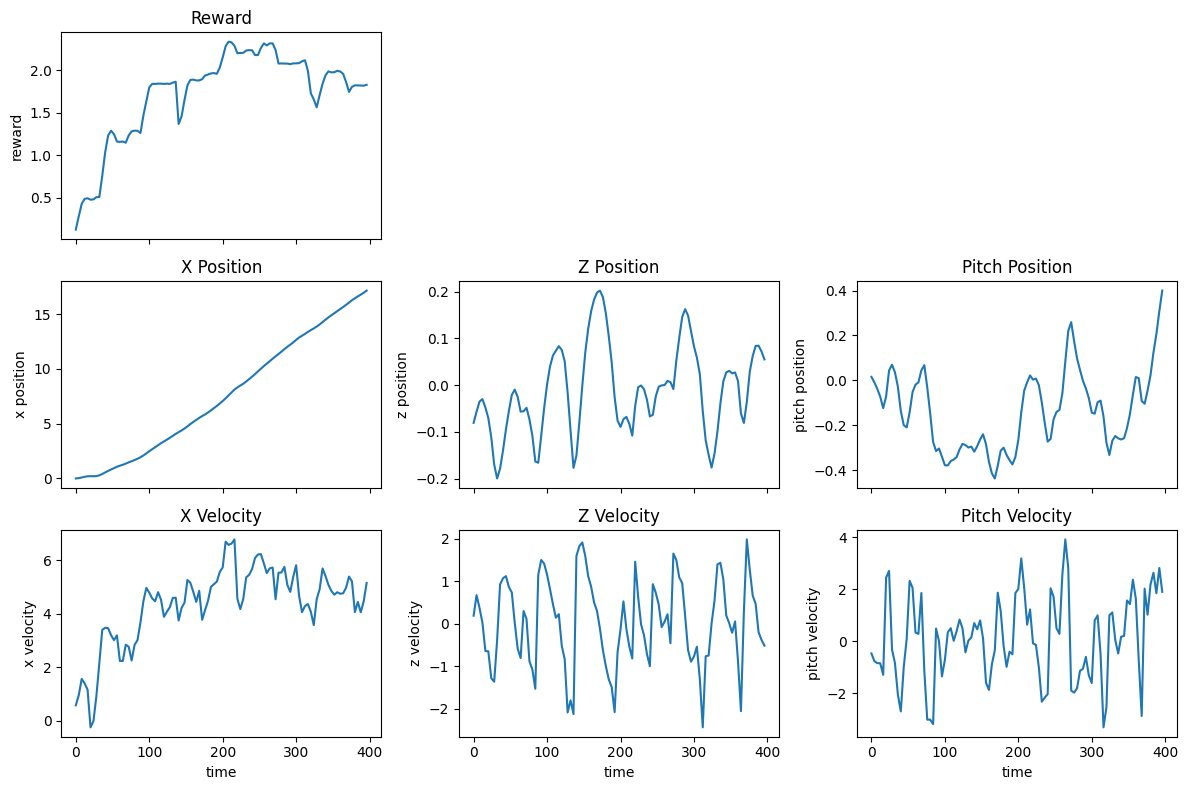

In [8]:
#@title {vertical-output: true}
import copy
import matplotlib.pyplot as plt

def visualize_log(ticks, rewards, frames, qposs, qvels):
    ticks = [tick*4 for tick in ticks]
    # Visualize results: Create multi-panel plot
    _, ax = plt.subplots(3, 3, sharex=True, figsize=(12, 8))

    # Convert qpos and qvel to numpy arrays
    qposs_array = np.asarray(qposs)  # Shape: (num_steps, qpos_dim)
    qvels_array = np.asarray(qvels)  # Shape: (num_steps, qvel_dim)

    # First row: Reward (span all 3 columns)
    ax[0, 0].plot(ticks, rewards)
    ax[0, 0].set_ylabel('reward')
    ax[0, 0].set_title('Reward')
    ax[0, 1].axis('off')  # Hide middle plot
    ax[0, 2].axis('off')  # Hide right plot

    # Second row: Positions (x, z, pitch) - individual plots
    ax[1, 0].plot(ticks, qposs_array[:, 0])
    ax[1, 0].set_ylabel('x position')
    ax[1, 0].set_title('X Position')

    ax[1, 1].plot(ticks, qposs_array[:, 1])
    ax[1, 1].set_ylabel('z position')
    ax[1, 1].set_title('Z Position')

    ax[1, 2].plot(ticks, qposs_array[:, 2])
    ax[1, 2].set_ylabel('pitch position')
    ax[1, 2].set_title('Pitch Position')

    # Third row: Velocities (x, z, pitch) - individual plots
    ax[2, 0].plot(ticks, qvels_array[:, 0])
    ax[2, 0].set_ylabel('x velocity')
    ax[2, 0].set_xlabel('time')
    ax[2, 0].set_title('X Velocity')

    ax[2, 1].plot(ticks, qvels_array[:, 1])
    ax[2, 1].set_ylabel('z velocity')
    ax[2, 1].set_xlabel('time')
    ax[2, 1].set_title('Z Velocity')

    ax[2, 2].plot(ticks, qvels_array[:, 2])
    ax[2, 2].set_ylabel('pitch velocity')
    ax[2, 2].set_xlabel('time')
    ax[2, 2].set_title('Pitch Velocity')

    plt.tight_layout()

random_state = np.random.RandomState(42)
np.random.seed(42)
env = MPC_ENV_GT(suite.load('cheetah', 'run', task_kwargs={'random': random_state}))
mirro_env = MPC_ENV_GT(suite.load('cheetah', 'run', task_kwargs={'random': random_state}))

# Set simulation duration and calculate number of steps
duration = 4.0  # seconds
num_steps = int(duration / env.control_timestep)

# ================================
# MPC INSTANTIATION
mpc_agent = MPC(mirro_env)

rewards = []
ticks = []
action_sequence = []
env.reset()

# Main simulation loop
for step in range(num_steps):
    # Plan: Get best action sequence via MPC and take first action
    current_state = env.get_state()

    if len(action_sequence) == 0:
      action_sequence = MPC.plan(mpc_agent, current_state)[:mpc_agent.execution_horizon]

    action, action_sequence = action_sequence[0], action_sequence[1:]

    # Execute: Apply action to environment
    reward = env.step(action,True)

    # Record: Collect data from this step
    rewards.append(reward)
    ticks.append(step)

    # Print progress every 10 steps
    if step % 10 == 0:
        print(f"Step {step}/{num_steps}, total reward: {sum(rewards):.2f}, avg reward: {np.mean(rewards):.4f}")

frames, qposs, qvels = env.get_log()
print(f"{len(frames)} frames, total reward: {sum(rewards):.2f}, avg reward: {np.mean(rewards):.4f}")
visualize_log(ticks, rewards, frames, qposs, qvels)

env.close()
mirro_env.close()
# Display video of the cheetah running
show_video(frames, fps=25)

## Grading and Evaluation for Part 1

Your controller will be evaluated in a single 4-second simulation rollout.

Except for the line:

    mpc_agent = MPC(mirro_env)

you are **not allowed to modify any other code in the evaluation cell**.

Your final score consists of the following components:

1. **Reward Performance (Up to 3 points)**  
   The accumulated reward determines your score according to the following thresholds:

   - Reward ≥ 100 → **3 points**
   - Reward ≥ 70 → **2 points**
   - Reward ≥ 40 → **1 point**
   - Reward < 40 → **0 points**
   
2. **Stability Penalty (-1 points)**  
   If the cheetah falls (i.e., the torso pitch angle exceeds the allowed threshold), an 1-point penalty will be applied to your final score.

3. **Time Limit (Mandatory Requirement)**  
   The total runtime must not exceed **5 minutes**.  
   If your implementation exceeds the time limit, you will receive **zero points** for this part.

Please design your controller carefully to balance performance, stability, and computational efficiency.


In [9]:
# ================================
# DO NOT MODIFY THIS CELL (EXCEPT MPC)
# ================================

import copy
import time
import matplotlib.pyplot as plt

# Initialize environment and MPC agent
random_state = np.random.RandomState(42)
np.random.seed(42)
env = MPC_ENV_GT(suite.load('cheetah', 'run', task_kwargs={'random': random_state}))
mirro_env = MPC_ENV_GT(suite.load('cheetah', 'run', task_kwargs={'random': random_state}))

# Set simulation duration and calculate number of steps
duration = 4.0  # seconds
num_steps = int(duration / env.control_timestep)

# Instantiate your MPC controller
# You may modify the MPC class implementation,
# but do NOT modify anything else in this cell.
# ================================
# YOUR CODE GOES HERE ONLY
mpc_agent = MPC(mirro_env)
# ================================

env.reset()

reward = 0.0
flipped = False
action_sequence = []

start_time = time.time()

for step in range(num_steps):

    # ---- Time limit check (5 minutes) ----
    if time.time() - start_time > 5 * 60:
        print("Time limit exceeded. Score = 0")
        reward = 0
        break

    current_state = env.get_state()

    # ---- Fall detection (pitch angle) ----
    if abs(current_state[2]) > np.pi / 2:
        flipped = True
    if len(action_sequence) == 0:
      action_sequence = MPC.plan(mpc_agent, current_state)[:mpc_agent.execution_horizon]

    action, action_sequence = action_sequence[0], action_sequence[1:]
    r = env.step(action)

    reward += r

env.close()
mirro_env.close()
# -------------------------
# Scoring
# -------------------------

# Reward score
if reward >= 100:
    reward_score = 3
elif reward >= 70:
    reward_score = 2
elif reward >= 40:
    reward_score = 1
else:
    reward_score = 0

# Stability penalty
if flipped:
    reward_score -= 1

# Clamp minimum score at 0
final_score_part1 = max(reward_score, 0)

print(f"Total Reward: {reward:.2f}")
print(f"Flipped: {flipped}")
print(f"Score for Part1: {final_score_part1}/3")

Total Reward: 171.80
Flipped: False
Score for Part1: 3/3


## **Part2: Model Predictive Control (MPC) with a Learned Forward Model**

In this part, you will collect data and train a Forward Model to approximate the system dynamics.

The Forward Model takes as input a 24-dimensional vector:

- 18-dimensional current state  
- 6-dimensional action  

These correspond to the dataset input **X**.

The model outputs the 18-dimensional next state, corresponding to the dataset target **Y**.

During evaluation, you must use your trained Forward Model inside MPC to replace the ground-truth (GT) simulator dynamics for trajectory prediction.



## Part 2.1 Data Collection


To train the model, you need to collect sufficient transition data of the form:

    X:(state_t, action_t) → Y:state_{t+1}

You should use MPC to generate meaningful trajectories for data collection.

Since training requires a sufficiently large dataset, you will likely need to perform multiple simulation rollouts.

Because of the time constraint, you may:

- Modify the MPC hyperparameters from Part 1 (e.g., reduce planning horizon or sample size), or  
- Design a new, faster MPC controller that sacrifices performance for speed during data collection.

Carefully balance data quality, dataset size, and computational efficiency.

---

Theoretically, **150 minutes** are enough for this part.  

In [10]:
#@title MPC for Part 2 (You can delete/comment this block if you are just changing the parameters){vertical-output: true}
# from collections import deque

# class MPC:
# # ================================
# # YOUR CODE GOES HERE
#     def __init__(self, env, planning_horizon=1, execution_horizon=1, num_samples=1, top_k=1):
#         self.env = env
#         self.planning_horizon = planning_horizon
#         self.execution_horizon = execution_horizon
#         self.num_samples = num_samples
#         self.top_k = top_k
#         self.action_spec = env.action_spec

#     def plan(self, current_state):

#         self.env.reset()
#         self.env.physics.set_state(current_state)
#         self.env.physics.forward()

#         return best_action_sequence

# print("MPC function defined")

In [11]:
#@title Data Collection Procedure {vertical-output: true}
import pickle, os

data_path = 'data_pt.pkl'

if os.path.exists(data_path):
    print(f"Dataset already exists at {data_path}, skipping data collection.")
else:

# ================================
# YOUR CODE GOES HERE
    # Initialize environment and MPC agent
    random_state = np.random.RandomState(42)
    np.random.seed(42)
    env = MPC_ENV_GT(suite.load('cheetah', 'run', task_kwargs={'random': random_state}))
    mirro_env = MPC_ENV_GT(suite.load('cheetah', 'run', task_kwargs={'random': random_state}))

    # Set simulation duration and calculate number of steps
    duration = 4.0  # seconds
    num_steps = int(duration / env.control_timestep)

    simulation_times = 150
    num_samples = simulation_times * num_steps

    current_state = env.get_state()
    input_shape = current_state.shape[0]
    action_shape = env.action_spec.shape[0]

    X = np.zeros((num_samples, input_shape+action_shape))
    Y = np.zeros((num_samples, input_shape))

    # Instantiate MPC agent (using mirror environment for planning)
    mpc_agent = MPC(mirro_env, 8, 2, 180, 50, 2)

    action_low = env.action_spec.minimum
    action_high = env.action_spec.maximum

    index = 0
    for sim in range(simulation_times):

        time_step = env.reset()
        mirro_env.reset()
        mpc_agent.prev_mean = None
        state = env.get_state()
        action_sequence = []

        for step in range(num_steps):

            # Plan using MPC (on mirror env)
            if len(action_sequence) == 0:
                action_sequence = mpc_agent.plan(state)[:mpc_agent.execution_horizon]
            action, action_sequence = action_sequence[0], action_sequence[1:]

            # Add modest exploration so the learned model sees more than one narrow gait.
            if np.random.rand() < 0.05:
                action = np.random.uniform(action_low, action_high)
            else:
                action = np.clip(action + 0.05 * np.random.randn(action_shape), action_low, action_high)

            # Apply first action only
            # Step real environment
            reward = env.step(action)
            next_state = env.get_state()
            # Store transition
            X[index, :] = np.concatenate([state, action])
            Y[index, :] = next_state
            index += 1
            # Update state
            state = next_state

            if index >= num_samples:
                break

        if index >= num_samples:
            break

    print(f"Collected {index} transitions.")
# ================================
    env.close()
    # Save the collected data in the data_pt3.pkl file
    data = {'X': X, 'Y': Y}
    pickle.dump(data, open(data_path, "wb" ))
    print(f"Saved {index} transitions.")

Collected 15000 transitions.
Saved 15000 transitions.


In [13]:
from google.colab import files
files.download('data_pt.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Part 2.2 Training a Forward Model

### Normalizer Definition

We provide you with the Mini-Max Normalizer Class  for the model training. **DO NOT CHANGE IT.**

In [14]:
# ================================
# DO NOT MODIFY THIS CELL
# ================================

class MiniMaxStateActionNormalizer:
    """Normalizer for states and actions using min-max scaling."""

    def __init__(self, normalization_range=(-1, 1)):
        """
        Initialize normalizer.

        Args:
            normalization_range: Tuple of (min, max) for normalization.
                                 Use (-1, 1) or (0, 1)
        """
        self.normalization_range = normalization_range

        self.state_min = None
        self.state_max = None
        self.action_min = None
        self.action_max = None
        self.next_state_min = None
        self.next_state_max = None

    def fit(self, states, actions, next_states=None):
        """
        Compute normalization statistics from training data.

        Args:
            states: numpy array or torch tensor (N, state_dim)
            actions: numpy array or torch tensor (N, action_dim)
            next_states: optional, numpy array or torch tensor (N, state_dim)
        """
        if isinstance(states, np.ndarray):
            states = torch.FloatTensor(states)
        if isinstance(actions, np.ndarray):
            actions = torch.FloatTensor(actions)

        # Compute min and max for states
        self.state_min = states.min(dim=0)[0]
        self.state_max = states.max(dim=0)[0]

        # Add small epsilon to avoid division by zero
        self.state_max = torch.maximum(self.state_max, self.state_min + 1e-8)

        # Compute min and max for actions
        self.action_min = actions.min(dim=0)[0]
        self.action_max = actions.max(dim=0)[0]

        # Add small epsilon to avoid division by zero
        self.action_max = torch.maximum(self.action_max, self.action_min + 1e-8)

        # Optionally compute min and max for next_states
        if next_states is not None:
            if isinstance(next_states, np.ndarray):
                next_states = torch.FloatTensor(next_states)
            self.next_state_min = next_states.min(dim=0)[0]
            self.next_state_max = next_states.max(dim=0)[0]
            self.next_state_max = torch.maximum(self.next_state_max, self.next_state_min + 1e-8)
        else:
            # Use same stats as states
            self.next_state_min = self.state_min
            self.next_state_max = self.state_max

    def normalize_state(self, state):
        """
        Normalize state to [normalization_range].

        Formula: x_norm = (x - min) / (max - min) * (range_max - range_min) + range_min
        """
        # Scale to [0, 1]
        state_01 = (state - self.state_min) / (self.state_max - self.state_min)

        # Scale to [normalization_range]
        range_min, range_max = self.normalization_range
        state_norm = state_01 * (range_max - range_min) + range_min

        return state_norm

    def normalize_action(self, action):
        """Normalize action to [normalization_range]."""
        # Scale to [0, 1]
        action_01 = (action - self.action_min) / (self.action_max - self.action_min)

        # Scale to [normalization_range]
        range_min, range_max = self.normalization_range
        action_norm = action_01 * (range_max - range_min) + range_min

        return action_norm

    def normalize_state_action(self, state, action):
        """Normalize and concatenate state and action."""
        state_norm = self.normalize_state(state)
        action_norm = self.normalize_action(action)
        return torch.cat([state_norm, action_norm], dim=-1)

    def normalize_next_state(self, next_state):
        """Normalize next state to [normalization_range]."""
        # Scale to [0, 1]
        next_state_01 = (next_state - self.next_state_min) / (self.next_state_max - self.next_state_min)

        # Scale to [normalization_range]
        range_min, range_max = self.normalization_range
        next_state_norm = next_state_01 * (range_max - range_min) + range_min

        return next_state_norm

    def denormalize_state(self, state_norm):
        """Denormalize state back to original scale."""
        # Scale from [normalization_range] to [0, 1]
        range_min, range_max = self.normalization_range
        state_01 = (state_norm - range_min) / (range_max - range_min)

        # Scale from [0, 1] to original range
        state = state_01 * (self.state_max - self.state_min) + self.state_min

        return state

    def denormalize_action(self, action_norm):
        """Denormalize action back to original scale."""
        # Scale from [normalization_range] to [0, 1]
        range_min, range_max = self.normalization_range
        action_01 = (action_norm - range_min) / (range_max - range_min)

        # Scale from [0, 1] to original range
        action = action_01 * (self.action_max - self.action_min) + self.action_min

        return action

    def denormalize_next_state(self, next_state_norm):
        """Denormalize next state back to original scale."""
        # Scale from [normalization_range] to [0, 1]
        range_min, range_max = self.normalization_range
        next_state_01 = (next_state_norm - range_min) / (range_max - range_min)

        # Scale from [0, 1] to original range
        next_state = next_state_01 * (self.next_state_max - self.next_state_min) + self.next_state_min

        return next_state

    def save(self, path):
        """Save normalization statistics."""
        torch.save({
            'normalization_range': self.normalization_range,
            'state_min': self.state_min,
            'state_max': self.state_max,
            'action_min': self.action_min,
            'action_max': self.action_max,
            'next_state_min': self.next_state_min,
            'next_state_max': self.next_state_max,
        }, path)

    def load(self, path):
        """Load normalization statistics."""
        checkpoint = torch.load(path)
        self.normalization_range = checkpoint['normalization_range']
        self.state_min = checkpoint['state_min']
        self.state_max = checkpoint['state_max']
        self.action_min = checkpoint['action_min']
        self.action_max = checkpoint['action_max']
        self.next_state_min = checkpoint['next_state_min']
        self.next_state_max = checkpoint['next_state_max']

print("Normalizer defined")

Normalizer defined


### Dataset Definition

We provide you with the Dataset class for the model training.  **You can modify it, but theoretically, there is no need to do so.**

In [15]:
from torch.utils.data import Dataset
class DynamicDataset(Dataset):
    def __init__(self, datafile, normalizer=None, fit_normalizer=False, state_dim=18, action_dim=6):
        data = pickle.load(open(datafile, 'rb'))
        self.X = data['X'].astype(np.float32)  # [state, action] shape: (N, 24)
        self.Y = data['Y'].astype(np.float32)  # [next_state] shape: (N, 18)

        self.state_dim = state_dim
        self.action_dim = action_dim
        self.normalizer = normalizer

        # Fit normalizer if requested
        if fit_normalizer and normalizer is not None:
            states = self.X[:, :state_dim]
            actions = self.X[:, state_dim:]
            next_states = self.Y

            print("Fitting normalizer on training data...")
            normalizer.fit(states, actions, next_states)
            print("Normalizer fitted!")
            self.normalizer.save('normalizer.pt')

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        x = self.X[idx]  # [state, action]
        y = self.Y[idx]  # [next_state]

        if self.normalizer is not None:
            # Extract state and action
            state = x[:self.state_dim]
            action = x[self.state_dim:]

            # Convert to torch tensors
            state = torch.FloatTensor(state)
            action = torch.FloatTensor(action)
            y = torch.FloatTensor(y)

            # Normalize inputs only; target is raw delta-state.
            state_norm = self.normalizer.normalize_state(state)
            action_norm = self.normalizer.normalize_action(action)
            x_norm = torch.cat([state_norm, action_norm], dim=0)
            y_delta = y - state

            return x_norm, y_delta
        else:
            # No normalization, just return as torch tensors
            state = torch.FloatTensor(x[:self.state_dim])
            next_state = torch.FloatTensor(y)
            return torch.FloatTensor(x), next_state - state

print("DynamicDataset defined")

DynamicDataset defined


### Forward Model Architecture Definition


In this section, you will design the neural network architecture for the Forward Model.

The overall objective is to learn a dynamics function of the form:

    X: (state_t, action_t) → Y: state_{t+1}

You are free to modify or extend the parameters in the `__init__` function as needed (e.g., hidden size, number of layers, activation functions, etc.).

A practical design choice is to concatenate the current state and action as the input to the network.

In practice, instead of directly predicting the next state, it is often more effective to predict the **state difference**:

    Δstate = state_{t+1} − state_t

The next state can then be computed as:

    state_{t+1} = state_t + Δstate

This residual formulation typically improves learning stability and accuracy, especially for dynamical systems.


In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

class Forward_Model(nn.Module):
# ================================
# YOUR CODE GOES HERE
    def __init__(
        self,
        state_dim=18,
        action_dim=6,
        hidden_dims=[256, 256, 256],
        activation=nn.ReLU,
    ):
        super(Forward_Model, self).__init__()

        self.state_dim = state_dim
        self.action_dim = action_dim
        self.input_dim = state_dim + action_dim

        layers = []
        prev_dim = self.input_dim

        for h_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, h_dim))
            layers.append(activation())
            prev_dim = h_dim

        # Output layer (predict Δstate)
        layers.append(nn.Linear(prev_dim, state_dim))
        self.network = nn.Sequential(*layers)

# ================================

    def forward(self, x):
# ================================
# YOUR CODE GOES HERE
        """
        x: Tensor of shape (batch_size, state_dim + action_dim)

        Returns:
            delta_state: Tensor of shape (batch_size, state_dim)
        """
        delta_state = self.network(x)
        return delta_state




### Training Function Definition

We provide you with the train and test functions for the model training. **You can modify it, but theoretically, there is no need to do so.**

In [17]:
import tqdm
import pickle
import time
import shutil
import os
import numpy as np

def train(model, train_loader, optimizer, criterion, device):
    model.train()
    train_loss = 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        y_pred = model(x)

        loss = criterion(y_pred, y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    return train_loss / len(train_loader)

def test(model, test_loader, criterion, device):
    model.eval()

    test_loss = 0
    with torch.no_grad():
      for x, y in test_loader:
          x, y = x.to(device), y.to(device)
          y_pred = model(x)
          loss = criterion(y_pred, y)

          test_loss += loss.item()
    return test_loss / len(test_loader)

print("Training functions defined")

Training functions defined


In [18]:
#@title{vertical-output: true}

import shutil
# ================================
# Do NOT change - We are only using CPU, and GPU is not allowed.
device = torch.device("cpu")
# ================================

normalizer = MiniMaxStateActionNormalizer()
dataset = DynamicDataset('data_pt.pkl', normalizer, fit_normalizer=True)
model_path = 'dynamics_pt.pth'

if os.path.exists(model_path):
    print(f"Model already exists at {model_path}, skipping training.")
else:
# ================================
# YOUR CODE GOES HERE
    split = 0.2
    dataset_size = len(dataset)
    test_size = int(np.floor(split * dataset_size))
    train_size = dataset_size - test_size

    torch.manual_seed(42)
    generator = torch.Generator().manual_seed(42)

    train_set, test_set = random_split(dataset, [train_size, test_size], generator=generator)

    train_loader = torch.utils.data.DataLoader(
        train_set, batch_size=128, shuffle=True, generator=generator
    )
    test_loader = torch.utils.data.DataLoader(
        test_set, batch_size=128, shuffle=False, generator=generator
    )

    timestr = time.strftime("%Y-%m-%d_%H-%M-%S")
    model_dir = os.path.join('models', timestr)
    if not os.path.isdir(model_dir):
        os.makedirs(model_dir)

    model = Forward_Model()
    epochs = 100

    best_test_loss = float('inf')
    best_model_path = None


    criterion = torch.nn.SmoothL1Loss()
    optimizer = torch.optim.Adam(model.parameters(), lr=3e-4, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.StepLR(
        optimizer, step_size=50, gamma=0.5
    )
    model.to(device)

    for epoch in range(1, 1 + epochs):

        train_loss = train(model, train_loader, optimizer, criterion, device)
        test_loss = test(model, test_loader, criterion, device)

        scheduler.step()

        print(
            f"Epoch {epoch:03d} | "
            f"Train Loss: {train_loss:.6f} | "
            f"Test Loss: {test_loss:.6f}"
        )

        # Save best model (model selection via validation loss)
        if test_loss < best_test_loss:
            best_test_loss = test_loss
            best_model_path = os.path.join(model_dir, "best_model.pth")
            torch.save(model.state_dict(), best_model_path)

# ================================
    shutil.copy(best_model_path, model_path)

    print(f"\nTraining complete! Best model saved to: {model_path}")
    print(f"Best test loss: {best_test_loss:.7f}")

Fitting normalizer on training data...
Normalizer fitted!
Epoch 001 | Train Loss: 0.014808 | Test Loss: 0.004647
Epoch 002 | Train Loss: 0.003885 | Test Loss: 0.003524
Epoch 003 | Train Loss: 0.003175 | Test Loss: 0.003082
Epoch 004 | Train Loss: 0.002829 | Test Loss: 0.002847
Epoch 005 | Train Loss: 0.002577 | Test Loss: 0.002639
Epoch 006 | Train Loss: 0.002395 | Test Loss: 0.002490
Epoch 007 | Train Loss: 0.002257 | Test Loss: 0.002401
Epoch 008 | Train Loss: 0.002142 | Test Loss: 0.002294
Epoch 009 | Train Loss: 0.002040 | Test Loss: 0.002179
Epoch 010 | Train Loss: 0.001926 | Test Loss: 0.002144
Epoch 011 | Train Loss: 0.001868 | Test Loss: 0.002068
Epoch 012 | Train Loss: 0.001794 | Test Loss: 0.001983
Epoch 013 | Train Loss: 0.001720 | Test Loss: 0.001919
Epoch 014 | Train Loss: 0.001666 | Test Loss: 0.001902
Epoch 015 | Train Loss: 0.001626 | Test Loss: 0.001843
Epoch 016 | Train Loss: 0.001567 | Test Loss: 0.001785
Epoch 017 | Train Loss: 0.001538 | Test Loss: 0.001815
Epoch 0

In [19]:
os.listdir()

['.config',
 'models',
 'normalizer.pt',
 'drive',
 'dynamics_pt.pth',
 'data_pt.pkl',
 'sample_data']

## Part 2.3 ModelPlaning through Forward Model

### Integrating the Forward Model with MPC

To apply your trained Forward Model within MPC, we provide a helper class:

- `Pesudo_Environment`

This class wraps your learned dynamics model and provide an interface similar to the wrapped environment used in **Part1**, enabling model-based rollout during planning.

You are **not allowed to modify any code** in this class, except for the part where you:

- Instantiate your trained Forward Model  
- Load the saved checkpoint

All other logic has been implemented for you and will be used during evaluation. Modifying other parts may lead to incorrect behavior or grading issues.

Please ensure that your model architecture and checkpoint loading are consistent with the implementation in this section.


In [20]:
# ================================
# DO NOT MODIFY THIS CELL (EXCEPT FOR MODEL INSTANTIATION)
# ================================

class MPC_ENV_FM:
  def __init__(self, model_path, device, normalizer):
    self.device = device
# ================================
# YOUR CODE GOES HERE ONLY
    # Instantiate model (make sure dimensions match training)
    self.model = Forward_Model()

    # Load trained weights
    checkpoint = torch.load(model_path, map_location=device)
    self.model.load_state_dict(checkpoint)

    # Move to device and set evaluation mode
    self.model.to(device)
    self.model.eval()

# ================================
    self.normalizer = normalizer

  def set_state(self, state):
      """Set the current physics state."""
      self.state = np.array(state, dtype=np.float32).copy()

  def get_state(self):
      """Get the current physics state."""
      return self.state.copy() if self.state is not None else None

  def step(self, action):
      state = self.state
      single_sample = (state.ndim == 1)
      if single_sample:
          state = state[np.newaxis, :]
          action = action[np.newaxis, :]
      state_torch = torch.FloatTensor(state).to(device)
      action_torch = torch.FloatTensor(action).to(device)

      with torch.no_grad():
          # Normalize
          state_norm = self.normalizer.normalize_state(state_torch)
          action_norm = self.normalizer.normalize_action(action_torch)
          state_action_norm = torch.cat([state_norm, action_norm], dim=-1)

          # Predict raw delta-state and add it to the current raw state.
          delta_state_torch = self.model(state_action_norm)
          next_state_torch = state_torch + delta_state_torch

      # Convert to numpy
      next_state = next_state_torch.cpu().numpy()

      if single_sample:
          next_state = next_state[0]

      self.state = next_state

  def reset(self):
      return
  def close(self):
      return

## Manually Testing the Controller Using Forward Model  

In this section, you will test your MPC controller again.  

Similar to **Part 1**, you will perform a rollout and evaluate performance. However, the key difference is:

- In Part 1, MPC performs planning using **ground-truth dynamics (the simulator)**.
- In this part, MPC performs planning using your **trained Forward Model**.

During planning, the predicted next state is generated by the Forward Model in an **auto-regressive manner**:

    s_{t+1} = f_\theta(s_t, a_t)


and the predicted state is recursively fed back into the model for multi-step rollout.

---

### Important Note

Although not strictly required, in practice it is often beneficial to use **the same MPC configuration** (e.g., horizon, sampling strategy) as used during data collection.  

This helps keep planning **in-distribution**, which typically leads to better prediction accuracy and higher overall reward.

---

Time Limit: **2 minutes** (For the grading)

Step 0/100, total reward: 0.05, avg reward: 0.0484
Step 10/100, total reward: 0.67, avg reward: 0.0608
Step 20/100, total reward: 0.90, avg reward: 0.0427
Step 30/100, total reward: 0.96, avg reward: 0.0309
Step 40/100, total reward: 1.05, avg reward: 0.0256
Step 50/100, total reward: 1.25, avg reward: 0.0245
Step 60/100, total reward: 1.37, avg reward: 0.0225
Step 70/100, total reward: 1.43, avg reward: 0.0202
Step 80/100, total reward: 1.52, avg reward: 0.0188
Step 90/100, total reward: 1.54, avg reward: 0.0170
100 frames, total reward: 1.60, avg reward: 0.0160


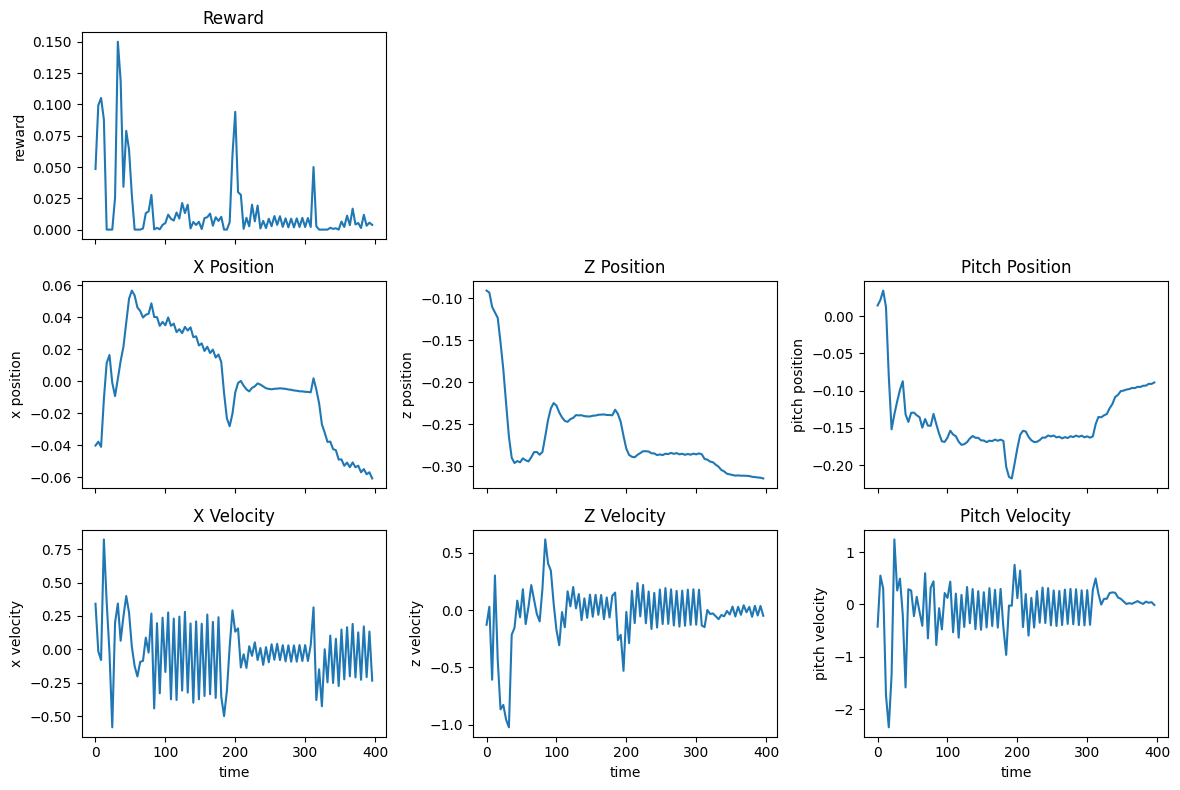

In [21]:
#@title {vertical-output: true}
import copy
import matplotlib.pyplot as plt

random_state = np.random.RandomState(42)
np.random.seed(42)
env = MPC_ENV_GT(suite.load('cheetah', 'run', task_kwargs={'random': random_state}))

# Set simulation duration and calculate number of steps
duration = 4.0  # seconds
num_steps = int(duration / env.control_timestep)

# ================================
# Do NOT change - We are only using CPU, and GPU is not allowed.
device = torch.device("cpu")
# ================================

normalizer = MiniMaxStateActionNormalizer()
if os.path.exists('normalizer.pt'):
  normalizer.load('normalizer.pt')
else:
  dataset = DynamicDataset('data_pt.pkl', normalizer, fit_normalizer=True)
  normalizer = dataset.normalizer

mirro_env = MPC_ENV_FM('dynamics_pt.pth', device, normalizer)
mirro_env.action_spec = env.action_spec

# ================================
# MPC INSTANTIATION
mpc_agent = MPC(mirro_env)

rewards = []
ticks = []
action_sequence = []
env.reset()

# Main simulation loop
for step in range(num_steps):
    # Plan: Get best action sequence via MPC and take first action
    current_state = env.get_state()

    if len(action_sequence) == 0:
      action_sequence = MPC.plan(mpc_agent, current_state)[:mpc_agent.execution_horizon]

    action, action_sequence = action_sequence[0], action_sequence[1:]

    # Execute: Apply action to environment
    reward = env.step(action,True)

    # Record: Collect data from this step
    rewards.append(reward)
    ticks.append(step)

    # Print progress every 10 steps
    if step % 10 == 0:
        print(f"Step {step}/{num_steps}, total reward: {sum(rewards):.2f}, avg reward: {np.mean(rewards):.4f}")

frames, qposs, qvels = env.get_log()
print(f"{len(frames)} frames, total reward: {sum(rewards):.2f}, avg reward: {np.mean(rewards):.4f}")
visualize_log(ticks, rewards, frames, qposs, qvels)

env.close()
mirro_env.close()
# Display video of the cheetah running
show_video(frames, fps=25)

## Grading and Evaluation for Part 2

Your controller will be evaluated in a single 4-second simulation rollout.

Except for the line:

    mpc_agent = MPC(sudo_env)

you are **not allowed to modify any other code in the evaluation cell**.

Your final score consists of the following components:

1. **Reward Performance (Up to 2 points)**  
   The accumulated reward determines your score according to the following thresholds:

   - Reward ≥ 60 → **2 points**
   - Reward ≥ 40 → **1 points**
   - Reward < 40 → **0 points**

2. **Stability Penalty (-1 points)**  
   If the cheetah falls (i.e., the torso pitch angle exceeds the allowed threshold), an 1-point penalty will be applied to your final score.

3. **Time Limit (Mandatory Requirement)**  
   The total runtime must not exceed **2 minutes**.  
   If your implementation exceeds the time limit, you will receive **zero points** for this part.

In [22]:
# ================================
# DO NOT MODIFY THIS CELL (EXCEPT MPC)
# ================================

import copy
import time
import matplotlib.pyplot as plt

# Initialize environment and MPC agent
random_state = np.random.RandomState(42)
np.random.seed(42)
env = MPC_ENV_GT(suite.load('cheetah', 'run', task_kwargs={'random': random_state}))

# Set simulation duration and calculate number of steps
duration = 4.0  # seconds
num_steps = int(duration / env.control_timestep)


device = torch.device("cpu")

normalizer = MiniMaxStateActionNormalizer()
if os.path.exists('normalizer.pt'):
  normalizer.load('normalizer.pt')
else:
  dataset = DynamicDataset('data_pt.pkl', normalizer, fit_normalizer=True)
  normalizer = dataset.normalizer

mirro_env = MPC_ENV_FM('dynamics_pt.pth', device, normalizer)
mirro_env.action_spec = env.action_spec
# Instantiate your MPC controller
# You may modify the MPC class implementation,
# but do NOT modify anything else in this cell.
# ================================
# YOUR CODE GOES HERE ONLY
mpc_agent = MPC(mirro_env)
# ================================

env.reset()

reward = 0.0
flipped = False
action_sequence = []

start_time = time.time()

for step in range(num_steps):

    # ---- Time limit check (2 minutes) ----
    if time.time() - start_time > 2 * 60:
        print("Time limit exceeded. Score = 0")
        reward = 0
        break

    current_state = env.get_state()

    # ---- Fall detection (pitch angle) ----
    if abs(current_state[2]) > np.pi / 2:
        flipped = True
    if len(action_sequence) == 0:
      action_sequence = MPC.plan(mpc_agent, current_state)[:mpc_agent.execution_horizon]

    action, action_sequence = action_sequence[0], action_sequence[1:]
    r = env.step(action)

    reward += r

env.close()
mirro_env.close()
# -------------------------
# Scoring
# -------------------------

# Reward score
if reward >= 60:
    reward_score = 2
elif reward >= 40:
    reward_score = 1
else:
    reward_score = 0

# Stability penalty
if flipped:
    reward_score -= 1

# Clamp minimum score at 0
final_score_part2 = max(reward_score, 0)

print(f"Total Reward: {reward:.2f}")
print(f"Flipped: {flipped}")
print(f"Score for Part2: {final_score_part2}/2")

Time limit exceeded. Score = 0
Total Reward: 0.00
Flipped: False
Score for Part2: 0/2


# Total Score Calculation

In [23]:
# ================================
# DO NOT MODIFY THIS CELL
# ================================
print(f"Final Score: {final_score_part1 + final_score_part2}/5")

Final Score: 3/5
